# Deflection of a Membrane
https://jsdokken.com/dolfinx-tutorial/chapter1/membrane.html, https://jsdokken.com/dolfinx-tutorial/chapter1/membrane_code.html <br>
Problem: Compute deflection $D(x,y)$ of a two-dimensional circular membrane of radius $R$ sunject to a load $p$ over the membrane. PDE model: <br>
$-T\Delta D = p ~ \text{in} ~ \Omega=\{(x,y)|x^2+y^2\leq R^2\}$ <br>
Where $T$ is the constant tension of the membrane and $p$ is the external pressure load. The boundary of the membrane has no deflection. This implies $D=0$ at the boundary. <br>
We model $p(x,y)$ as a Gaussian function. <br>
With a lot of scaling we get the scaled problem: <br>
$-\Delta \omega = 4\exp(-\beta^2(x^2+(y-R_0)^2))$ to be solved over the unit disc with $\omega=0$ on the boundary. Now there are only two parameters which vary the dimensionless extent of the pressure, $\beta$, and the location of the pressure peak, $R_0\in [0,1]$. As $\beta \to 0$, the solution will approach the special case $\omega = 1-x^2-y^2$. Given a computed scaled solution $\omega$ the physical deflection can be computed by $D = \frac{AR^2}{8\pi\sigma T} \omega$.


### Creation of the mesh with GMSH

In [1]:
import gmsh

gmsh.initialize() # gmsh is a CAD software

In [2]:
membrane = gmsh.model.occ.addDisk(0,0,0,1,1) # create the membrane at centre coordinates (0,0,0) with x-radius=1, y-radius=1
gmsh.model.occ.synchronize() # generate the relevant underlying data structures

In [3]:
gdim = 2
gmsh.model.addPhysicalGroup(gdim, [membrane], 1) # make membrane a physical surface s.t. it is recognized by gmsh when generating the mesh. 

1

Make the membrane a physical surface, such that it is recognized by gmsh when generating the mesh. As a surface is a two-dimensional entity, we add 2 as the first argument, the entity tag of the membrane as the second argument, and the physical tag as the last argument. In a later demo, we will get into when this tag matters.

In [4]:
# Create two-dimensional mesh
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.05)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.05) # set uniform mesh size
gmsh.model.mesh.generate(gdim)

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.000164095s, CPU 0.000115s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0354979s, CPU 0.035275s)
Info    : 1550 nodes 3099 elements


### Interfacing with GMSH in DOLFINx
We will import the GMSH-mesh directly from GMSH into DOLFINx via the `dolfinx.io.gmsh` interface.
The `dolfinx.io.gmsh` module contains two functions
1. `model_to_mesh` which takes in a `gmsh.model`
  and returns a `dolfinx.io.gmsh.MeshData` object.
2. `read_from_msh` which takes in a path to a `.msh`-file
 and returns a `dolfinx.io.gmsh.MeshData` object.

The `MeshData` object will contain a `dolfinx.mesh.Mesh`,
under the attribute `mesh<dolfinx.io.gmsh.MeshData.mesh>`.
This mesh will contain all GMSH Physical Groups of the highest topological dimension.
```{note}
If you do not use `gmsh.model.addPhysicalGroup` when creating the mesh with GMSH, it can not be read into DOLFINx.
```
The `MeshData<dolfinx.io.gmsh.MeshData>` object can also contain tags for
all other `PhysicalGroups` that has been added to the mesh, that being
`cell_tags<dolfinx.io.gmsh.MeshData.cell_tags>`, `facet_tags<dolfinx.io.gmsh.MeshData.facet_tags>`,
`ridge_tags<dolfinx.io.gmsh.MeshData.ridge_tags>` and
`peak_tags<dolfinx.io.gmsh.MeshData.peak_tags>`.
To read either `gmsh.model` or a `.msh`-file, one has to distribute the mesh to all processes used by DOLFINx.
As GMSH does not support mesh creation with MPI, we currently have a `gmsh.model.mesh` on each process.
To distribute the mesh, we have to specify which process the mesh was created on,
and which communicator rank should distribute the mesh.
The `model_to_mesh<dolfinx.io.gmsh.model_to_mesh>` will then load the mesh on the specified rank,
and distribute it to the communicator using a mesh partitioner.

In [5]:
from dolfinx.io import gmsh as gmshio
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI

gmsh_model_rank = 0
mesh_comm = MPI.COMM_WORLD
mesh_data = gmshio.model_to_mesh(gmsh.model, mesh_comm, gmsh_model_rank, gdim=gdim)
assert mesh_data.cell_tags is not None
cell_markers = mesh_data.cell_tags
domain = mesh_data.mesh

In [6]:
from dolfinx import fem

# Create functionspace
V = fem.functionspace(domain, ("Lagrange", 1))

### Define right hand side

In [7]:
# Define right hand side
import ufl
from dolfinx import default_scalar_type

x = ufl.SpatialCoordinate(domain)
beta = fem.Constant(domain, default_scalar_type(12)) # constant 
R0 = fem.Constant(domain, default_scalar_type(0.3)) # also constant
p = 4 * ufl.exp(- (beta**2)*(x[0]**2 + (x[1] - R0)**2))

### Create Dirichlet boundary using geometrical conditions
We can use the `locate_dofs_geometrical` method to locate the degrees of freedom on the boundary. As we know that our domain is a circle with radius 1, we know that any degree of freedom should be located at a coordinate $(x,y)$ such that $\sqrt{x^2+y^2} = 1$.

In [8]:
import numpy as np

def on_boundary(x):
    return np.isclose(np.sqrt(x[0]**2 + x[1]**2), 1)

boundary_dofs = fem.locate_dofs_geometrical(V, on_boundary)

In [9]:
bc = fem.dirichletbc(default_scalar_type(0), boundary_dofs, V) # u=0 on boundary -> Dirichlet has constant value

### Define the variational problem
(Same as Poisson)

In [10]:
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = p*v*ufl.dx

problem = LinearProblem(a, L, bcs = [bc], 
                        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
                        petsc_options_prefix="membrane_",
                        )
uh = problem.solve()

### Interpolation of a ufl-expression
As we previously defined the load $p$ as a spatially varying function, we would like to interpolate this function into an appropriate function space for visualization. To do this we use the class `Expression`. The expression takes in any ufl-expression and a set of points on the reference element. We will use the `interpolation points` of the space we want to interpolate in to. We choose a high order function space to represent the function $p$ as it is rapidly varying in space.

In [11]:
Q = fem.functionspace(domain, ("Lagrange", 5))
expr = fem.Expression(p, Q.element.interpolation_points)
pressure = fem.Function(Q)
pressure.interpolate(expr)

### Plot

In [12]:
from dolfinx.plot import vtk_mesh
import pyvista as pv
pv.set_jupyter_backend("html")

#### Plot deflection $u_h$ over domain $\Omega$

In [13]:
# Extract topology from mesh and create unstructured grid
topology, cell_types, x = vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, x)
# Set deflection values and add it to plotter
grid.point_data["u"] = uh.x.array
warped = grid.warp_by_scalar("u", factor = 25)

plotter = pv.Plotter()
plotter.add_mesh(warped, show_edges=True, show_scalar_bar=True, scalars="u")
if not pv.OFF_SCREEN:
    plotter.show()

2026-03-04 15:53:15.789 (   0.689s) [    75106AA8F600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

#### Plot the load on the domain

In [14]:
load_plotter = pv.Plotter()
p_grid = pv.UnstructuredGrid(*vtk_mesh(Q))
p_grid.point_data["p"] = pressure.x.array.real
warped_p = p_grid.warp_by_scalar("p", factor = 0.5)
warped_p.set_active_scalars("p")
load_plotter.add_mesh(warped_p, show_scalar_bar=True)
load_plotter.view_xy()
if not pv.OFF_SCREEN:
    load_plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

#### Making curve plots throughout the domain
We want to plot along the line $x=0$. This is just a matter of defining a set of points along the $y$-axis and evaluating the finite element functions $u$ and $p$ at these points.

In [15]:
tol = 0.001 # Avoid hitting the outside of the domain
y = np.linspace(-1 + tol, 1 - tol, 101)
points = np.zeros((3, 101))
points[1] = y
u_values = []
p_values = []

As a finite element function is the linear combination of all degrees of freedom,
$u_h(x)=\sum_{i=1}^N c_i \phi_i(x)$ where $c_i$ are the coefficients of $u_h$ and $\phi_i$
is the $i$-th basis function, we can compute the exact solution at any point in $\Omega$.
However, as a mesh consists of a large set of degrees of freedom (i.e. $N$ is large),
we want to reduce the number of evaluations of the basis function $\phi_i(x)$.
We do this by identifying which cell of the mesh $x$ is in.
This is efficiently done by creating a `bounding box tree`
of the cells of the mesh,
allowing a quick recursive search through the mesh entities.

In [19]:
from dolfinx import geometry

bb_tree = geometry.bb_tree(domain, domain.topology.dim)

Now we can compute which cells the bounding box tree collides with using `dolfinx.geometry.compute_collisions_points()`. This function returns a list of cells whose bounding box collide for each input point. As different points might have different number of cells, the data is stored in `dolfinx.graph.AdjacencyList`, where one can access the cells for the ith point by calling `links(i)`. However, as the bounding box of a cell spans more of $\mathbb{R}^n$ than the actual cell, we check that the actual cell collides with the input point using `dolfinx.geometry.compute_colliding_cells()`, which measures the exact distance between the point and the cell (approximated as a convex hull for higher geometries). This function also returns an adjacency-list, as the point might align with a facet, edge or vertex that is shared between multiple cells in the mesh. <br>

Finally, we would like the code below to run in parallel, when the mesh is distributed over multiple processors. In that case, it is not guaranteed that every point in `points` is on each processor. Therefore we create a subset `point_on_proc` only containing the points found on the current processor.

In [34]:
cells = []
points_on_proc = []
# Find cells whose bounding-box collides with the points
cell_candidates = geometry.compute_collisions_points(bb_tree, points.T)
# Choose one of the cells that contains the point
colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points.T)
for i, point in enumerate(points.T):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])

We now have a list of points on the processor, on in which cell each point belongs. We can call `uh.eval` and `pressure.eval` to obtain the set of values for all the points.

In [27]:
points_on_proc = np.array(points_on_proc, dtype=np.float64)
u_values = uh.eval(points_on_proc, cells)
p_values = pressure.eval(points_on_proc, cells)

The beautiful thing is: I built a function for this, so now I can just evaluate easily as shown below.

In [23]:
from visualization_fct import evaluate_fct
points_on_proc, fct_values = evaluate_fct(domain, points, [uh, pressure])
u_values = fct_values[0]
p_values = fct_values[1]

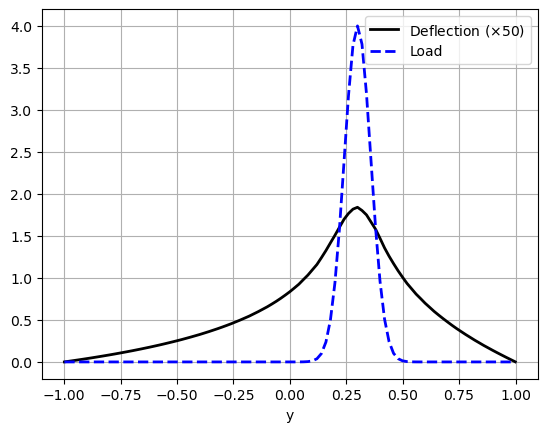

In [17]:
# Now we can use matplotlib to plot them

import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot(
    points_on_proc[:, 1],
    50 * u_values,
    "k",
    linewidth=2,
    label="Deflection ($\\times 50$)",
)
plt.plot(points_on_proc[:, 1], p_values, "b--", linewidth=2, label="Load")
plt.grid(True)
plt.xlabel("y")
plt.legend()

There is also a small part about saving the functions to file to later use Paraview to visualize the solution.

In [25]:
type(u_values)

numpy.ndarray